## 简单实现

In [44]:
import random
import torch
from d2l import torch as d2l

In [45]:
def synthetic_data(w, b, num_examples):
    # 生成 y=Xw+b+噪声
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))


true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print(features[0], labels[0])

tensor([0.7494, 0.2726]) tensor([4.7795])


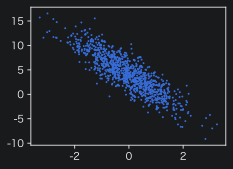

In [46]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1)

In [47]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [48]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, y)
    break

tensor([[ 0.8763,  1.4416],
        [ 0.9116, -0.6078],
        [-0.3447, -0.2545],
        [ 0.1745,  0.3267],
        [-2.2529, -0.8286],
        [-0.4830,  1.1971],
        [ 0.9126, -1.4040],
        [-0.8100, -0.9416],
        [ 0.6762,  0.5889],
        [-0.5765,  1.0621]]) tensor([[ 1.0384],
        [ 8.0905],
        [ 4.3637],
        [ 3.4511],
        [ 2.5043],
        [-0.8447],
        [10.7950],
        [ 5.7699],
        [ 3.5643],
        [-0.5646]])


上边已经准备好了实验数据

下边开始准备训练

In [49]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [50]:
def linreg(X, w, b):
    # 线性回归模型
    return torch.matmul(X, w) + b

In [51]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [52]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [53]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(epoch, train_l.mean())

0 tensor(0.0338)
1 tensor(0.0001)
2 tensor(4.9162e-05)


In [54]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0004,  0.0008], grad_fn=<SubBackward0>)
b的估计误差: tensor([2.6703e-05], grad_fn=<RsubBackward1>)


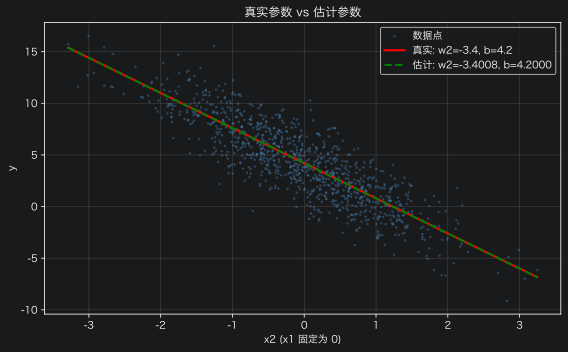

In [55]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

# 可视化固定 x1=0，沿 x2 轴展示（X~N(0,1)，x1 均值为 0）
x2_vals = features[:, 1].detach().numpy()
y_vals  = labels.detach().numpy().flatten()

x_line = torch.linspace(float(features[:, 1].min()), float(features[:, 1].max()), 200)

# 真实直线：y = true_w[1]*x2 + true_b（x1=0）
y_true_line = (true_w[1] * x_line + true_b).numpy()

# 估计直线：y = w[1]*x2 + b（x1=0）
with torch.no_grad():
    y_pred_line = (w[1] * x_line + b).numpy().flatten()

plt.figure(figsize=(8, 5))
plt.scatter(x2_vals, y_vals, s=3, alpha=0.3, color='steelblue', label='数据点')
plt.plot(x_line.numpy(), y_true_line, 'r-',  linewidth=2,
         label=f'真实: w2={true_w[1]:.1f}, b={true_b}')
plt.plot(x_line.numpy(), y_pred_line, 'g--', linewidth=2,
         label=f'估计: w2={w[1].item():.4f}, b={b.item():.4f}')
plt.xlabel('x2 (x1 固定为 0)')
plt.ylabel('y')
plt.title('真实参数 vs 估计参数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()